Fetching INR pairs (10y, daily)...
  fetched USD_INR (INR=X): 2601 rows
  fetched GBP_INR (GBPINR=X): 2602 rows
  fetched EUR_INR (EURINR=X): 2602 rows
  fetched JPY_INR (JPYINR=X): 2601 rows
  fetched CHF_INR (CHFINR=X): 2602 rows

Fetching USD cross-rates (for decomposition)...
  fetched EUR_USD (EURUSD=X): 2601 rows
  fetched GBP_USD (GBPUSD=X): 2601 rows
  fetched USD_JPY (USDJPY=X): 2601 rows
  fetched USD_CHF (USDCHF=X): 2601 rows

--- Rebased performance chart ---
  saved chart to inr_rebased_performance.png

--- Annualized volatility by pair ---
CHF_INR    12.39
JPY_INR    12.04
EUR_INR     9.47
GBP_INR     9.38
USD_INR     5.99
dtype: float64

--- Decomposing EUR/INR move: INR weakness vs EUR strength ---

Cumulative % change from 2016-07-06 to 2026-07-06:
EUR_INR    46.19
EUR_USD     3.21
dtype: float64

--- Correlation with Nifty 50 ---

Correlation (USD/INR daily returns vs Nifty 50 daily returns): -0.145

--- Event window analysis ---
                 USD_INR  GBP_INR  EUR

/tmp/ipykernel_28718/1891872673.py:117: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined = pd.concat([fx_series, equity_hist], axis=1).dropna()


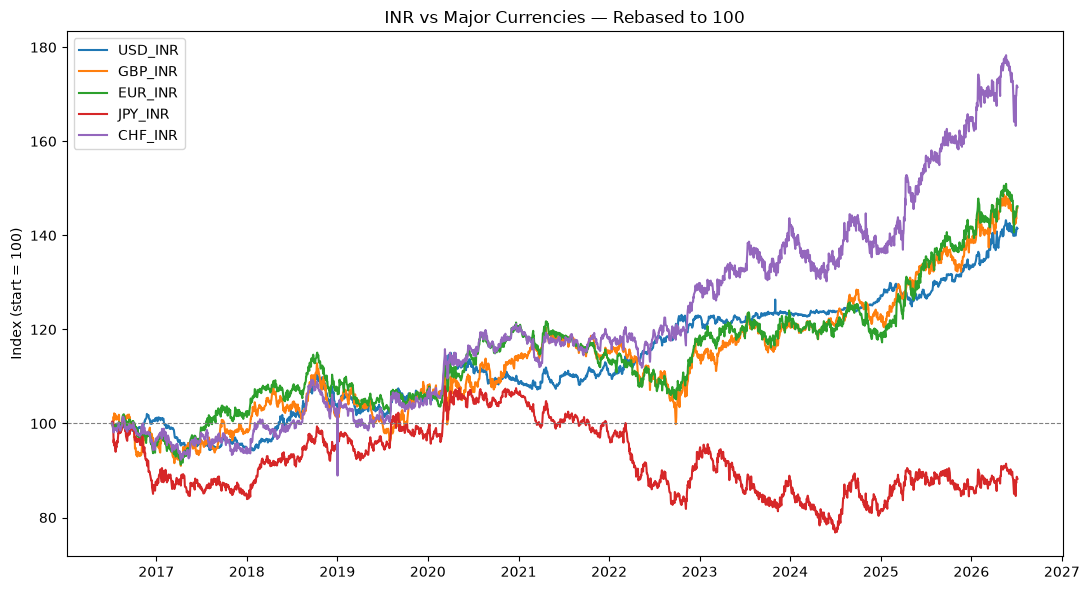

In [1]:
"""
INR Multi-Currency Analysis — Starter Script
==============================================

Analyzes the Indian Rupee against USD, GBP, EUR, JPY, CHF.

Install deps:
    pip install yfinance pandas numpy matplotlib requests

Run:
    python inr_currency_analysis.py
"""

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------
# 1. FETCH DATA
# -----------------------------------------------------------------------

# INR crosses (all quoted as "1 unit of foreign currency = X INR")
INR_PAIRS = {
    "USD_INR": "INR=X",
    "GBP_INR": "GBPINR=X",
    "EUR_INR": "EURINR=X",
    "JPY_INR": "JPYINR=X",
    "CHF_INR": "CHFINR=X",
}

# Cross-rates vs USD, to help separate "INR weakness" from "other currency strength"
CROSS_VS_USD = {
    "EUR_USD": "EURUSD=X",
    "GBP_USD": "GBPUSD=X",
    "USD_JPY": "USDJPY=X",
    "USD_CHF": "USDCHF=X",
}


def fetch_fx_data(tickers, period="10y", interval="1d"):
    data = {}
    for label, symbol in tickers.items():
        try:
            hist = yf.Ticker(symbol).history(period=period, interval=interval)
            if not hist.empty:
                data[label] = hist["Close"]
                print(f"  fetched {label} ({symbol}): {len(hist)} rows")
            else:
                print(f"  WARNING: no data for {label} ({symbol})")
        except Exception as e:
            print(f"  ERROR fetching {label} ({symbol}): {e}")
    df = pd.DataFrame(data)
    df.index = pd.to_datetime(df.index).tz_localize(None)
    return df.dropna(how="all")


# -----------------------------------------------------------------------
# 2. ANALYSIS 1 — Rebased comparison (has INR weakened more vs some currencies?)
# -----------------------------------------------------------------------

def plot_rebased(df, base=100, save_path="inr_rebased_performance.png"):
    """Rebase each INR pair to 100 at the start date. Rising line = INR weakening
    against that currency; falling line = INR strengthening."""
    clean = df.dropna()
    indexed = clean / clean.iloc[0] * base
    plt.figure(figsize=(11, 6))
    for col in indexed.columns:
        plt.plot(indexed.index, indexed[col], label=col)
    plt.axhline(base, color="gray", linewidth=0.8, linestyle="--")
    plt.title("INR vs Major Currencies — Rebased to 100")
    plt.ylabel("Index (start = 100)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    print(f"  saved chart to {save_path}")


# -----------------------------------------------------------------------
# 3. ANALYSIS 2 — Volatility comparison across pairs
# -----------------------------------------------------------------------

def compute_volatility(df):
    """Annualized volatility of daily returns per pair."""
    daily_returns = df.pct_change().dropna()
    ann_vol = daily_returns.std() * np.sqrt(252) * 100
    return ann_vol.sort_values(ascending=False).round(2)


# -----------------------------------------------------------------------
# 4. ANALYSIS 3 — Is EUR/INR move about INR or about EUR/USD?
# -----------------------------------------------------------------------

def decompose_cross_moves(inr_df, usd_cross_df):
    """
    Compare cumulative % change in e.g. EUR_INR vs EUR_USD over the same window.
    If EUR_INR rose a lot but EUR_USD barely moved, INR weakness (not EUR strength)
    explains most of the move -- and vice versa.
    """
    combined = pd.concat([inr_df, usd_cross_df], axis=1).dropna()
    start, end = combined.index[0], combined.index[-1]
    pct_change = (combined.iloc[-1] / combined.iloc[0] - 1) * 100
    print(f"\nCumulative % change from {start.date()} to {end.date()}:")
    print(pct_change.round(2))
    return pct_change


# -----------------------------------------------------------------------
# 5. ANALYSIS 4 — Correlation with Nifty 50 (risk-on/risk-off behavior)
# -----------------------------------------------------------------------

def correlation_with_equity(fx_series, equity_ticker="^NSEI", period="10y"):
    """Correlate daily USD/INR returns with Nifty 50 returns.
    Negative correlation = INR tends to weaken when equities fall (classic risk-off)."""
    equity_hist = yf.Ticker(equity_ticker).history(period=period, interval="1d")["Close"]
    equity_hist.index = pd.to_datetime(equity_hist.index).tz_localize(None)
    combined = pd.concat([fx_series, equity_hist], axis=1).dropna()
    combined.columns = ["FX", "Equity"]
    returns = combined.pct_change().dropna()
    corr = returns["FX"].corr(returns["Equity"])
    print(f"\nCorrelation (USD/INR daily returns vs Nifty 50 daily returns): {corr:.3f}")
    return corr


# -----------------------------------------------------------------------
# 6. ANALYSIS 5 — Event window drawdown/recovery comparison
# -----------------------------------------------------------------------

EVENT_WINDOWS = {
    "2018_Rate_Hikes": ("2018-01-01", "2018-12-31"),
    "2020_COVID": ("2020-02-01", "2020-06-30"),
    "2022_Fed_Hiking": ("2022-01-01", "2022-12-31"),
}

def event_window_analysis(df, windows=EVENT_WINDOWS):
    """% change in each INR pair during known stress periods."""
    results = {}
    for event, (start, end) in windows.items():
        window = df.loc[start:end].dropna()
        if len(window) < 2:
            continue
        pct_change = (window.iloc[-1] / window.iloc[0] - 1) * 100
        results[event] = pct_change
    return pd.DataFrame(results).T.round(2)


# -----------------------------------------------------------------------
# 7. MAIN
# -----------------------------------------------------------------------

if __name__ == "__main__":
    print("Fetching INR pairs (10y, daily)...")
    inr_df = fetch_fx_data(INR_PAIRS)

    print("\nFetching USD cross-rates (for decomposition)...")
    usd_cross_df = fetch_fx_data(CROSS_VS_USD)

    print("\n--- Rebased performance chart ---")
    plot_rebased(inr_df)

    print("\n--- Annualized volatility by pair ---")
    vol = compute_volatility(inr_df)
    print(vol)

    print("\n--- Decomposing EUR/INR move: INR weakness vs EUR strength ---")
    decompose_cross_moves(inr_df[["EUR_INR"]], usd_cross_df[["EUR_USD"]])

    print("\n--- Correlation with Nifty 50 ---")
    correlation_with_equity(inr_df["USD_INR"])

    print("\n--- Event window analysis ---")
    events = event_window_analysis(inr_df)
    print(events)

    inr_df.to_csv("inr_pairs_data.csv")
    print("\nDone. Data saved to inr_pairs_data.csv, chart saved to inr_rebased_performance.png")